## Installing Packages
Installing the API package to extract the retail datasets directly from the UCI Machine Learning Repository, as well as importing the necessary packages required to perform Data Exploration and Modelling.

In [1]:
#command is commented out when the installation is completed
#!pip install ucimlrepo

In [25]:
#importing the required packages
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV,StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

In [3]:
#loading the dataset based on the ID, found in the URL of each one
session=fetch_ucirepo(id=468)

The returned object is a consolidation of the actual data, and the metadata of the datasets. Therefore, it is required that we save only the actual dataframe for the Exploratory Data Analysis. 
To extract only the dataframe, we must use the .data container that has multiple dataframes within it (i.e, only target variables, only input variables etc.). We use this container along with .original to obtain the entire dataframe exactly as the UCI ML repository hosts it.

In [4]:
session_data=session.data.original

In [5]:
#ensuring the number of rows and columns match with the dataset description and inspecting the first few rows in the datasets
print("The number of rows and columns for the Online Shoppers Purchasing Intention Dataset (The session data):",session_data.shape)
print(session_data.info())

The number of rows and columns for the Online Shoppers Purchasing Intention Dataset (The session data): (12330, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser       

The session data has a target variable, Revenue, a binary variable stating whether a session resulted in a purchase or not. Hence, the dataset can be used to train supervised learning models, i.e classification models.
Before building the model, we need to understand the structure of the data, which means understanding whether the classes in the target variable are balanced or not.

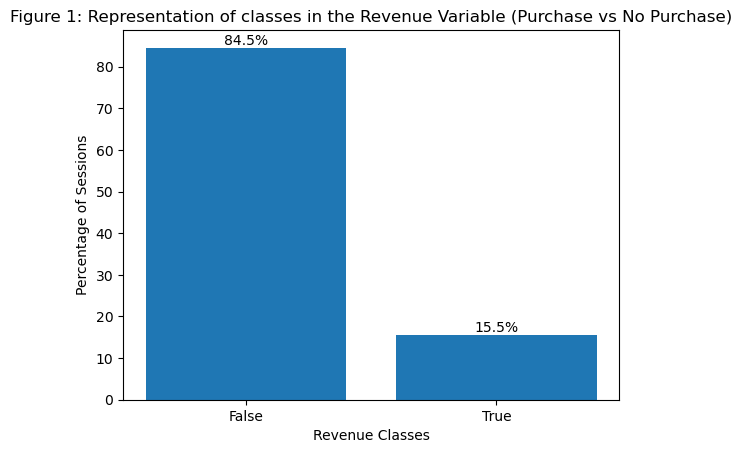

In [6]:
target_perc=session_data["Revenue"].value_counts(normalize=True)*100
fig,axes=plt.subplots()
bars=axes.bar(target_perc.index.astype(str),target_perc.values)
axes.bar_label(bars,labels=[f"{p:.1f}%" for p in target_perc])
axes.set_title("Figure 1: Representation of classes in the Revenue Variable (Purchase vs No Purchase)")
axes.set_xlabel("Revenue Classes")
axes.set_ylabel("Percentage of Sessions")
plt.show()

Figure 1 displays the class imbalance present in the Online Shoppers Purchasing Intention Dataset. From the bar graph it is evident that the sessions that resulted in no purchases dominate the dataset. This is integral to acknowledge, since a model can obtain a high accuracy just by predicting every session as a no purchase, with learning any patterns from the data. To account for this imbalance, Precision, Recall and Macro F1 score will be used to evaluate the model.
The Precision will identify how often predicted buyers purchase items, which will be relevant to the efficiency in marketing budget. Recall will identify how many real buyers were accurately identified, which is associated with avoiding potential revenue opportunities. The F1 score combines both, giving an equal weightage to both classes.

## Classification Model
### Support Vector Machines (SVMs)
To classify the session data into whether a session results in a purchase or not we use the Support Vector Machine Classifier algorithm. This algorithm finds the most optimal line that can accurately and confidently separate the sessions that resulted in a purchase and those that did not, and maximizes the distance between the two groups (reference)

In [7]:
#separating the input features and the target variable
input_features=session_data.drop(columns="Revenue")
target=session_data["Revenue"]

In [8]:
#splitting the dataset into training and test sets
input_train,input_test,target_train,target_test=train_test_split(input_features,target,test_size=0.30,stratify=target,random_state=28)

The data is split using the argument stratify, to compensate for the obvious class imbalance in dataset, where approximately 80% of the sessions resulted in no purchase. The test size is 30% of the data, leaving 70% for training.

Some columns like Month and VisitorType are stored as object (text) variables, which cannot be plotted on a coordinate axis. Therefore, it is required that they are converted from the human-readable format to a format that the machine can read. However, converting these columns into numeric values from 0-9 would imply that they have an inherent order, which is not the case. Therefore, sklearn's OneHotEncoder is used to convert the nominal columns into machine-readable formats.

It is also noted that some variables like Region, Operating Systems etc. are categorical variables that are encoded as numbers from 0-9, which is implying an order in the data. These columns are also encoded using the OneHotEncoder.

In [9]:
cat_columns=["Month","OperatingSystems","Browser","Region","TrafficType","VisitorType"]
#the encoder produces N-1 columns for every session, where N is the number of categories found in that variable
#the output will be a dense readable array
#if the encoder every sees a category that has never been identified before it just encodes it with all zeros
e=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
e.fit(input_train[cat_columns])
#transforming the training and test sets
train_transformed=e.transform(input_train[cat_columns])
test_transformed=e.transform(input_test[cat_columns])
new_cols=e.get_feature_names_out(cat_columns)
train_set=pd.DataFrame(train_transformed,columns=new_cols,index=input_train.index)
test_set=pd.DataFrame(test_transformed,columns=new_cols,index=input_test.index)

#creating the final training and test sets
input_train_encoded=input_train.drop(columns=cat_columns).join(train_set)
input_test_encoded=input_test.drop(columns=cat_columns).join(test_set)

print(input_train_encoded.shape)
print(input_test_encoded.shape)

(8631, 68)
(3699, 68)


Now, since all the categorical columns are encoded using the OneHotEncoder, the number of columns have drastically increased, this is because every category in the 6 categorical columns is converted into a column name. Now, since the SVM measures the distance between points to identify the optimal line separating the two classes, it is important that all numerical columns are on the same scale, to avoid the large differences between variables distorting the model.

In [10]:
num_cols=["Administrative","Administrative_Duration","Informational","Informational_Duration","ProductRelated","ProductRelated_Duration",
          "BounceRates","ExitRates","PageValues","SpecialDay"]
print(session_data[num_cols].skew())
#all the numeric columns produced a very large skew, therefore, before using the standard scaler the log transformation is applied
for c in num_cols:
    input_train_encoded[c]=np.log1p(input_train_encoded[c])
    input_test_encoded[c]=np.log1p(input_test_encoded[c])
scaler=StandardScaler()
input_train_encoded[num_cols]=scaler.fit_transform(input_train_encoded[num_cols])
input_test_encoded[num_cols]=scaler.transform(input_test_encoded[num_cols])


Administrative             1.960357
Administrative_Duration    5.615719
Informational              4.036464
Informational_Duration     7.579185
ProductRelated             4.341516
ProductRelated_Duration    7.263228
BounceRates                2.947855
ExitRates                  2.148789
PageValues                 6.382964
SpecialDay                 3.302667
dtype: float64


Before the kernel for the SVM is decided, a T-SNE plot is constructed to visualize the separation between both the classes. The plot will reduce the number of features to 2, so that a human can easily interpret them. If there exists a proper separation between the two classes, a linear kernel can be used to obtain the optimal line separating the two classes.

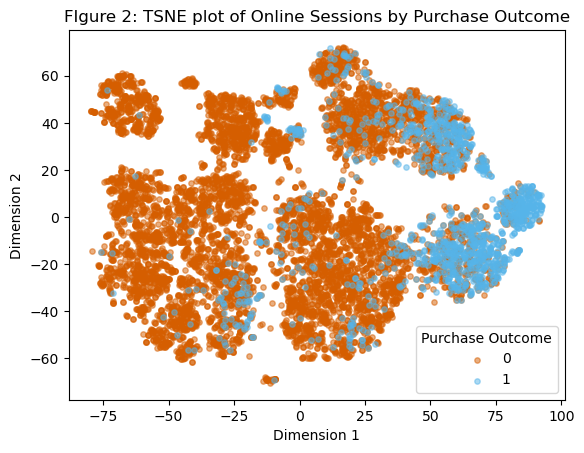

In [11]:
tsne=TSNE(n_components=2,random_state=28).fit_transform(input_train_encoded)
plt.figure()
for label,colour in zip([0,1],['#D55E00','#56B4E9']):
    mask=target_train.values.astype(int)==label
    plt.scatter(tsne[mask,0],tsne[mask,1],s=15,c=colour,label=label,alpha=0.5)
plt.title("FIgure 2: TSNE plot of Online Sessions by Purchase Outcome")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Purchase Outcome")
plt.show()

Figure 2 displays a small concentrated region of sessions that resulted in a purcharse which could possibly support the use of a linear kernel which would result in a straight line separating the two classes. However, there exists an ample number of purchase sessions that overlap with non-purchase sessions suggesting that there exists a real feature-space ambiguity. To identify which kernel is appropriate for this kind of data, both the linear and the rbf kernel will be evaluated using different score metrics.

In [13]:
#before building the Linear SVC model, the regularization parameter is tuned using a grid search with cross validation
CV=StratifiedKFold(n_splits=5,shuffle=True,random_state=28)
parameter_grid_svm={"C":[0.1,0.5,1,1.5,10,100]}
grid_search_svm=GridSearchCV(estimator=LinearSVC(class_weight="balanced",random_state=28),param_grid=parameter_grid_svm,scoring="f1",cv=CV)
grid_search_svm.fit(input_train_encoded,target_train)
print("The best regularization parameter for the LinearCV",grid_search_svm.best_params_)
print("This parameter will give the best F1 score of:",grid_search_svm.best_score_)



The best regularization parameter for the LinearCV {'C': 0.1}
This parameter will give the best F1 score of: 0.6682112325549704


In [ ]:
#using a linear kernel, based on the TSNE plot to find the optimal line separating the classes
svm=LinearSVC(class_weight="balanced",random_state=28, C=grid_search_svm.best_params_["C"]) #reference this
svm.fit(input_train_encoded,target_train)

LinearSVC(C=0.1, class_weight='balanced', random_state=28)

In [16]:
#predicting the revenue variable
predicted=svm.predict(input_test_encoded)

In [17]:
# calculating all the metrics required to evaluate the model, along with the classification report
precision= precision_score(target_test, predicted)
recall=recall_score(target_test, predicted)
f1=f1_score(target_test, predicted)
print(f"Precision:{precision:.2f}")
print(f"Recall:{recall:.2f}")
print(f"F1 Score:{f1:.2f}")
print(classification_report(target_test,predicted))

Precision:0.58
Recall:0.77
F1 Score:0.66
              precision    recall  f1-score   support

       False       0.96      0.90      0.92      3127
        True       0.58      0.77      0.66       572

    accuracy                           0.88      3699
   macro avg       0.77      0.83      0.79      3699
weighted avg       0.90      0.88      0.88      3699



In [34]:
#obtaining the weights of the variables from the LinearSVC model
names=input_train_encoded.columns
weights=svm.coef_[0]
#creating a dataframe containing the variables and their correspnding coefficients
coeff_df=pd.DataFrame({
    "Variable (Feature)":names,
    "Coefficients":weights
}).sort_values("Coefficients",ascending=False)
coeff_df["Coefficients"]=coeff_df["Coefficients"].abs()
coeff_df.head(10)

,Variable (Feature),Coefficients
8,PageValues,0.554065
25,OperatingSystems_7,0.370060
53,TrafficType_8,0.265990
17,Month_Nov,0.255770
37,Browser_12,0.247352
26,OperatingSystems_8,0.241507
56,TrafficType_11,0.210774
50,TrafficType_5,0.173841
65,TrafficType_20,0.168709
52,TrafficType_7,0.149996


In [38]:
#counting the instances of each encoded variables
for col in ["OperatingSystems","TrafficType","Browser"]:
    print(session_data[col].value_counts())

OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79
6      19
7       7
5       6
Name: count, dtype: int64
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64
Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
13      61
7       49
12      10
11       6
9        1
Name: count, dtype: int64


## Random Forest

In [ ]:
#cv is same
parameter_grid_randomf={"n_estimators":[10,20,50,100,300,400]}
grid_search_randomf=GridSearchCV(estimator=RandomForestClassifier(class_weight="balanced",random_state=28),param_grid=parameter_grid_randomf,scoring="f1",cv=CV)
grid_search_randomf.fit(input_train_encoded,target_train)
print("The optimal number of trees in the Random Forest will be",grid_search_randomf.best_params_)
print("This parameter will give the best F1 score of:",grid_search_randomf.best_score_)

The optimal number of trees in the Random Forest will be {'n_estimators': 50}
This parameter will give the best F1 score of: 0.6206506840505197


In [28]:
# building the RandomForestClassifier based on optimal estimators
randomforest=RandomForestClassifier(n_estimators=grid_search_randomf.best_params_["n_estimators"],class_weight="balanced",
                                    random_state=28,max_depth=None)
randomforest.fit(input_train_encoded,target_train)
predicted_rf=randomforest.predict(input_test_encoded)
precision_rf= precision_score(target_test, predicted_rf)
recall_rf=recall_score(target_test, predicted_rf)
f1_rf=f1_score(target_test, predicted_rf)
print(f"Precision:{precision_rf:.2f}")
print(f"Recall:{recall_rf:.2f}")
print(f"F1 Score:{f1_rf:.2f}")
print(classification_report(target_test,predicted_rf))

Precision:0.74
Recall:0.50
F1 Score:0.59
              precision    recall  f1-score   support

       False       0.91      0.97      0.94      3127
        True       0.74      0.50      0.59       572

    accuracy                           0.89      3699
   macro avg       0.82      0.73      0.77      3699
weighted avg       0.89      0.89      0.89      3699



In [29]:
importantfeatures_df=pd.DataFrame({
    "Variable (Feature)":input_train_encoded.columns,
    "Features":randomforest.feature_importances_,
}).sort_values("Features",ascending=False)
importantfeatures_df.head(10)

,Variable (Feature),Features
8,PageValues,0.371304
7,ExitRates,0.088283
5,ProductRelated_Duration,0.079014
4,ProductRelated,0.068815
6,BounceRates,0.050349
1,Administrative_Duration,0.049107
0,Administrative,0.040741
17,Month_Nov,0.026678
3,Informational_Duration,0.022285
2,Informational,0.017094


## Churn Analysis

In [69]:
#reading in the dataset for churn analysis
churn_data=pd.read_excel("churn_dataset.xlsx",sheet_name="E Comm")

In [70]:
#inspecting the data
print(churn_data.shape)
print(churn_data.info())

(5630, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberO

From the info() method, it is noted some variables, such as OrderCount, CouponsUsed, etc, have missing values. Further inspection is done to find all the columns.

In [71]:
#finding the columns with missing values
print(churn_data.isnull().sum())

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


In [72]:
# imputing the missing values in the columns using the median
cols_missing=churn_data.columns[churn_data.isnull().sum()>0].tolist()

#it is assumed that the WarehouseToHome variable would depend on the CityTier, since the address in lower city tiers might inevitably be further away from a Warehouse
churn_data["WarehouseToHome"]=churn_data.groupby("CityTier")["WarehouseToHome"]\
    .transform(lambda x:x.fillna(x.median()))
other_cols_missing=[col for col in cols_missing if col!="WarehouseToHome"]
for col in other_cols_missing:
    churn_data[col]=churn_data[col].fillna(churn_data[col].median())

In [101]:
obj_cols=churn_data.select_dtypes(include="object").columns.to_list()
for col in obj_cols:
    print(churn_data[col].value_counts())
#some duplicate terms exist in the categorical variables, to ensure robust and accurate predictions they must be investigated
churn_data["PreferredPaymentMode"]=churn_data["PreferredPaymentMode"].replace({"COD":"Cash on Delivery","CC":"Credit Card"})
churn_data["PreferedOrderCat"]=churn_data["PreferedOrderCat"].replace({"Phone":"Mobile Phone"})

PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64
Gender
Male      3384
Female    2246
Name: count, dtype: int64
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


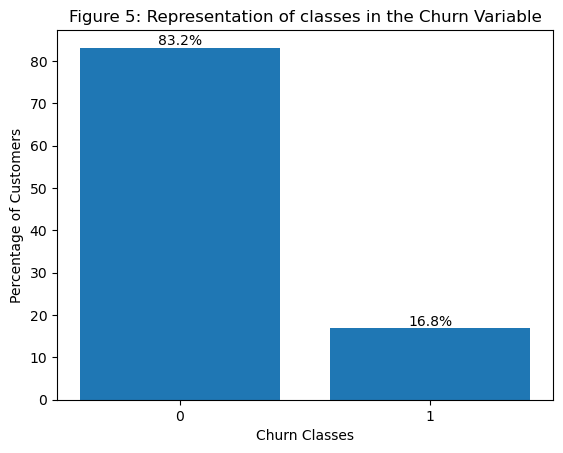

In [102]:
churn_perc=churn_data["Churn"].value_counts(normalize=True)*100
fig,axes=plt.subplots()
bars=axes.bar(churn_perc.index.astype(str),churn_perc.values)
axes.bar_label(bars,labels=[f"{p:.1f}%" for p in churn_perc])
axes.set_title("Figure 5: Representation of classes in the Churn Variable")
axes.set_xlabel("Churn Classes")
axes.set_ylabel("Percentage of Customers")
plt.show()

In [103]:
#stating the input features and target variable
#the customerID is a unique key, which will not provide any information to the models
input_churn_features=churn_data.drop(columns=["CustomerID","Churn"])
target_churn=churn_data["Churn"]

In [104]:
#splitting the dataset into training and test sets
input_churn_train,input_churn_test,target_churn_train,target_churn_test=train_test_split(input_churn_features,target_churn,test_size=0.30,stratify=target_churn,random_state=28)

In [105]:
#note that the CityTier, which is an int object is also add since storing it as a number would imply order rather than mapping
cat_churn_columns=["PreferredLoginDevice","CityTier","PreferredPaymentMode","Gender","PreferedOrderCat","MaritalStatus"]
#the output will be a dense readable array
#if the encoder every sees a category that has never been identified before it just encodes it with all zeros
e_churn=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
e_churn.fit(input_churn_train[cat_churn_columns])
#transforming the training and test sets
train_churn_transformed=e_churn.transform(input_churn_train[cat_churn_columns])
test_churn_transformed=e_churn.transform(input_churn_test[cat_churn_columns])
new_churn_cols=e_churn.get_feature_names_out(cat_churn_columns)
train_churn_set=pd.DataFrame(train_churn_transformed,columns=new_churn_cols,index=input_churn_train.index)
test_churn_set=pd.DataFrame(test_churn_transformed,columns=new_churn_cols,index=input_churn_test.index)

#creating the final training and test sets
input_churn_train_encoded=input_churn_train.drop(columns=cat_churn_columns).join(train_churn_set)
input_churn_test_encoded=input_churn_test.drop(columns=cat_churn_columns).join(test_churn_set)

print(input_churn_train_encoded.shape)
print(input_churn_test_encoded.shape)

(3941, 28)
(1689, 28)


In [106]:
#finding the skew in the numeric columns so there is no large affect on the models that compute the distance between points
numeric_churn_cols=["Tenure","WarehouseToHome","HourSpendOnApp","NumberOfDeviceRegistered","NumberOfAddress",
                    "SatisfactionScore","OrderAmountHikeFromlastYear","CouponUsed","OrderCount","DaySinceLastOrder","CashbackAmount"]
print(churn_data[numeric_churn_cols].skew())
#some numeric columns are not skewed and therefore do not need the log transformation
skew_cols=churn_data[numeric_churn_cols].columns[churn_data[numeric_churn_cols].skew().abs()>0.5].to_list()
for c in numeric_churn_cols:
    input_churn_train_encoded[c]=np.log1p(input_churn_train_encoded[c])
    input_churn_test_encoded[c]=np.log1p(input_churn_test_encoded[c])
scaler=StandardScaler()
input_churn_train_encoded[numeric_churn_cols]=scaler.fit_transform(input_churn_train_encoded[numeric_churn_cols])
input_churn_test_encoded[numeric_churn_cols]=scaler.transform(input_churn_test_encoded[numeric_churn_cols])

Tenure                         0.773278
WarehouseToHome                1.685535
HourSpendOnApp                -0.040982
NumberOfDeviceRegistered      -0.396969
NumberOfAddress                1.088639
SatisfactionScore             -0.142626
OrderAmountHikeFromlastYear    0.835439
CouponUsed                     2.630035
OrderCount                     2.276640
DaySinceLastOrder              1.273530
CashbackAmount                 1.149846
dtype: float64


In [107]:
#before building the Linear SVC model, the regularization parameter is tuned using a grid search with cross validation
parameter_grid_svm_churn={"C":[0.1,0.5,1,1.5,10,100]}
grid_search_svm_churn=GridSearchCV(estimator=LinearSVC(class_weight="balanced",random_state=28),param_grid=parameter_grid_svm_churn,scoring="f1",cv=CV)
grid_search_svm_churn.fit(input_churn_train_encoded,target_churn_train)
print("The best regularization parameter for the LinearCV",grid_search_svm_churn.best_params_)
print("This parameter will give the best F1 score of:",grid_search_svm_churn.best_score_)


The best regularization parameter for the LinearCV {'C': 0.1}
This parameter will give the best F1 score of: 0.6272068145350979


In [108]:
#using a linear kernel  to find the optimal line separating the classes
svm_churn=LinearSVC(class_weight="balanced",random_state=28, C=grid_search_svm_churn.best_params_["C"]) #reference this
svm_churn.fit(input_churn_train_encoded,target_churn_train)

LinearSVC(C=0.1, class_weight='balanced', random_state=28)

In [109]:
predicted_churn=svm_churn.predict(input_churn_test_encoded)

In [110]:
# calculating all the metrics required to evaluate the model, along with the classification report
precision_svm_churn= precision_score(target_churn_test, predicted_churn)
recall_svm_churn=recall_score(target_churn_test, predicted_churn)
f1_svm_churn=f1_score(target_churn_test, predicted_churn)
print(f"Precision:{precision_svm_churn:.2f}")
print(f"Recall:{recall_svm_churn:.2f}")
print(f"F1 Score:{f1_svm_churn:.2f}")
print(classification_report(target_churn_test,predicted_churn))

Precision:0.48
Recall:0.79
F1 Score:0.60
              precision    recall  f1-score   support

           0       0.95      0.83      0.88      1405
           1       0.48      0.79      0.60       284

    accuracy                           0.82      1689
   macro avg       0.71      0.81      0.74      1689
weighted avg       0.87      0.82      0.84      1689



In [111]:
coeff_churn_df=pd.DataFrame({
    "Variable (Feature)":input_churn_train_encoded.columns,
    "Coefficients":svm_churn.coef_[0]
}).sort_values("Coefficients",ascending=False)
coeff_df["Coefficients"]=coeff_df["Coefficients"].abs()
coeff_churn_df.head(10)

,Variable (Feature),Coefficients
6,Complain,0.558807
27,MaritalStatus_Single,0.247421
15,CityTier_3,0.225709
14,CityTier_2,0.220906
5,NumberOfAddress,0.195428
25,PreferedOrderCat_Others,0.173324
4,SatisfactionScore,0.149302
9,OrderCount,0.131990
3,NumberOfDeviceRegistered,0.117829
20,Gender_Male,0.113632


## Random Forest

In [112]:
parameter_grid_randomf_churn={"n_estimators":[10,20,50,100,300,400]}
grid_search_randomf_churn=GridSearchCV(estimator=RandomForestClassifier(class_weight="balanced",random_state=28),param_grid=parameter_grid_randomf_churn,scoring="f1",cv=CV)
grid_search_randomf_churn.fit(input_churn_train_encoded,target_churn_train)
print("The optimal number of trees in the Random Forest will be",grid_search_randomf_churn.best_params_)
print("This parameter will give the best F1 score of:",grid_search_randomf_churn.best_score_)

The optimal number of trees in the Random Forest will be {'n_estimators': 400}
This parameter will give the best F1 score of: 0.825373585700701


In [113]:
randomforest_churn=RandomForestClassifier(n_estimators=grid_search_randomf_churn.best_params_["n_estimators"],class_weight="balanced",
                                    random_state=28,max_depth=None)
randomforest_churn.fit(input_churn_train_encoded,target_churn_train)
predicted_rf_churn=randomforest_churn.predict(input_churn_test_encoded)
precision_rf_churn= precision_score(target_churn_test, predicted_rf_churn)
recall_rf_churn=recall_score(target_churn_test, predicted_rf_churn)
f1_rf_churn=f1_score(target_churn_test, predicted_rf_churn)
print(f"Precision:{precision_rf_churn:.2f}")
print(f"Recall:{recall_rf_churn:.2f}")
print(f"F1 Score:{f1_rf_churn:.2f}")
print(classification_report(target_churn_test,predicted_rf_churn))

Precision:0.96
Recall:0.77
F1 Score:0.85
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1405
           1       0.96      0.77      0.85       284

    accuracy                           0.96      1689
   macro avg       0.96      0.88      0.91      1689
weighted avg       0.96      0.96      0.95      1689



In [114]:
important_churn_features_df=pd.DataFrame({
    "Variable (Feature)":input_churn_train_encoded.columns,
    "Features":randomforest_churn.feature_importances_,
}).sort_values("Features",ascending=False)
important_churn_features_df.head(10)

,Variable (Feature),Features
0,Tenure,0.256904
11,CashbackAmount,0.099364
6,Complain,0.066686
1,WarehouseToHome,0.066276
10,DaySinceLastOrder,0.062901
7,OrderAmountHikeFromlastYear,0.051486
5,NumberOfAddress,0.051057
4,SatisfactionScore,0.044757
3,NumberOfDeviceRegistered,0.031924
9,OrderCount,0.029876
